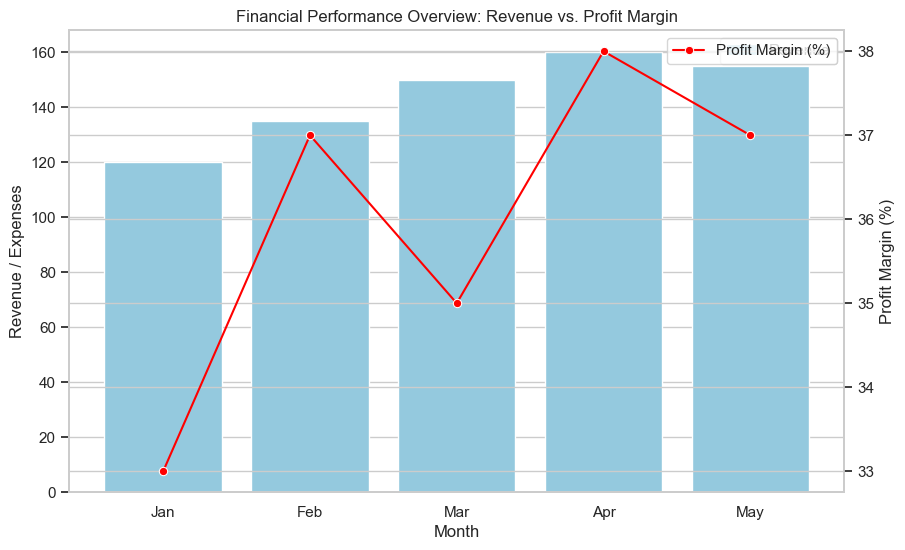

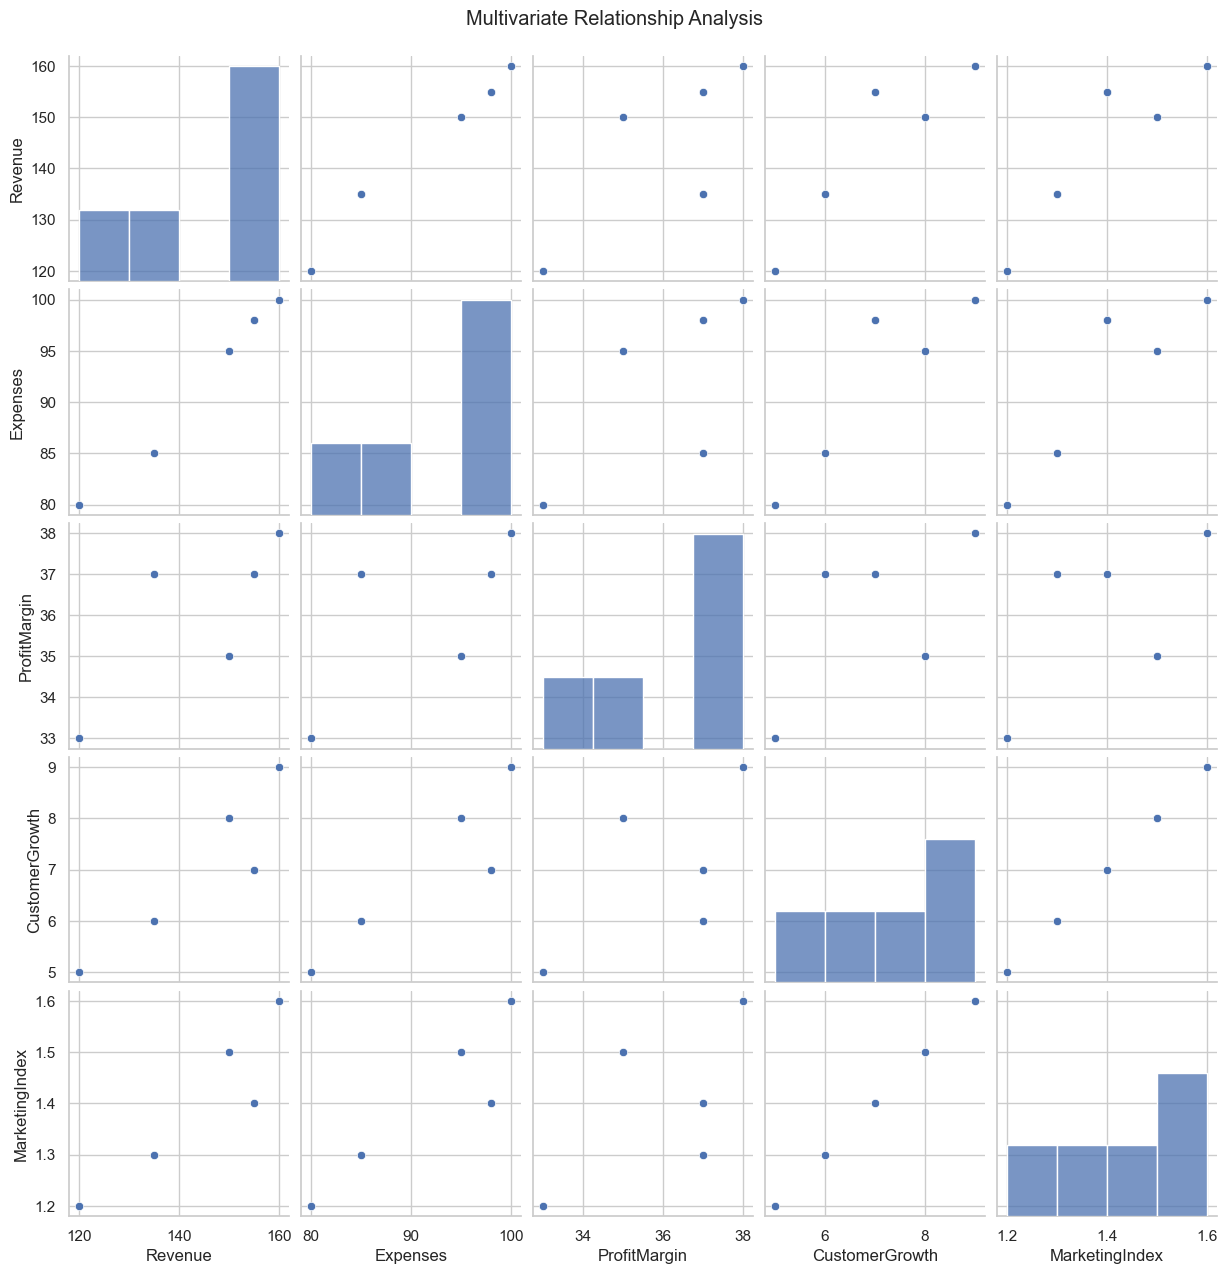

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the dataset from the provided table
data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May'],
    'Revenue': [120, 135, 150, 160, 155],
    'Expenses': [80, 85, 95, 100, 98],
    'ProfitMargin': [33, 37, 35, 38, 37],
    'CustomerGrowth': [5, 6, 8, 9, 7],
    'MarketingIndex': [1.2, 1.3, 1.5, 1.6, 1.4]
}

df = pd.DataFrame(data)

# Set the aesthetic style
sns.set_theme(style="whitegrid")

# Create a figure with subplots for multivariate analysis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Revenue as a Bar Chart
sns.barplot(x='Month', y='Revenue', data=df, ax=ax1, color='skyblue', label='Revenue')

# Create a second y-axis for Profit Margin as a Line Chart
ax2 = ax1.twinx()
sns.lineplot(x='Month', y='ProfitMargin', data=df, ax=ax2, marker='o', color='red', label='Profit Margin (%)')

# Final formatting
ax1.set_title('Financial Performance Overview: Revenue vs. Profit Margin')
ax1.set_ylabel('Revenue / Expenses')
ax2.set_ylabel('Profit Margin (%)')
plt.show()

# Pairplot to see relationships between all variables
sns.pairplot(df.drop('Month', axis=1))
plt.suptitle('Multivariate Relationship Analysis', y=1.02)
plt.show()

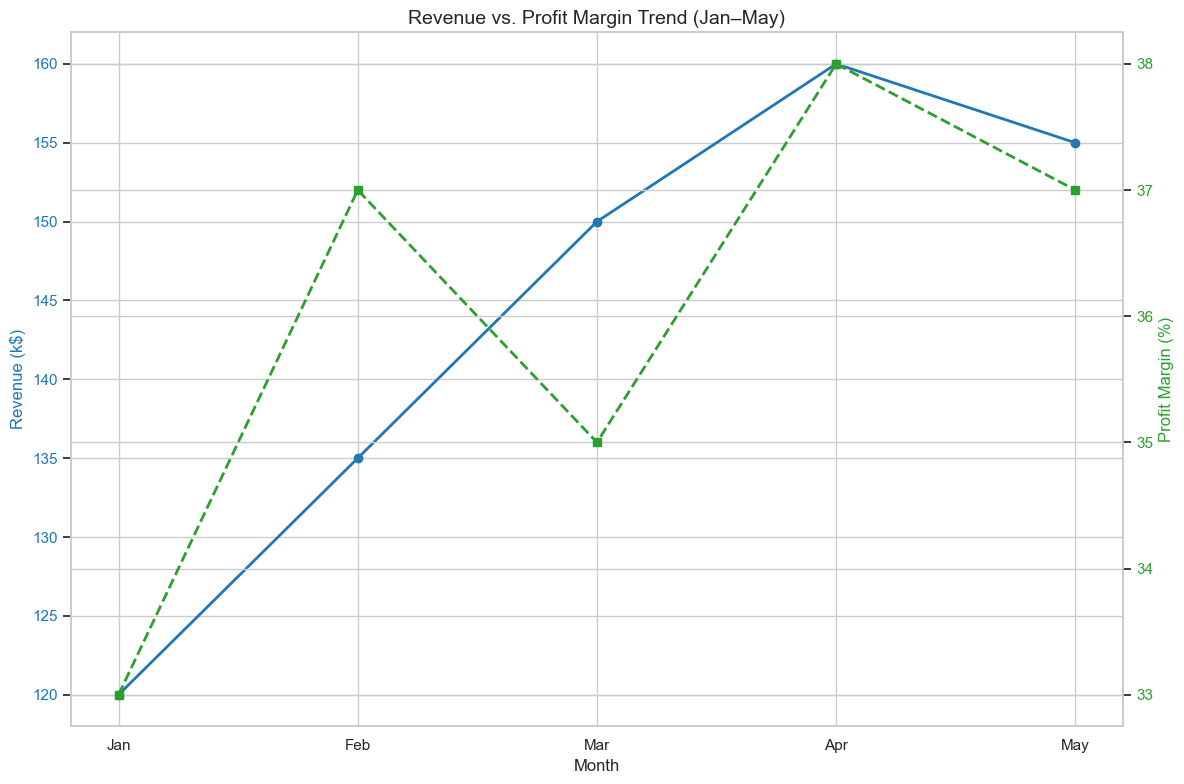

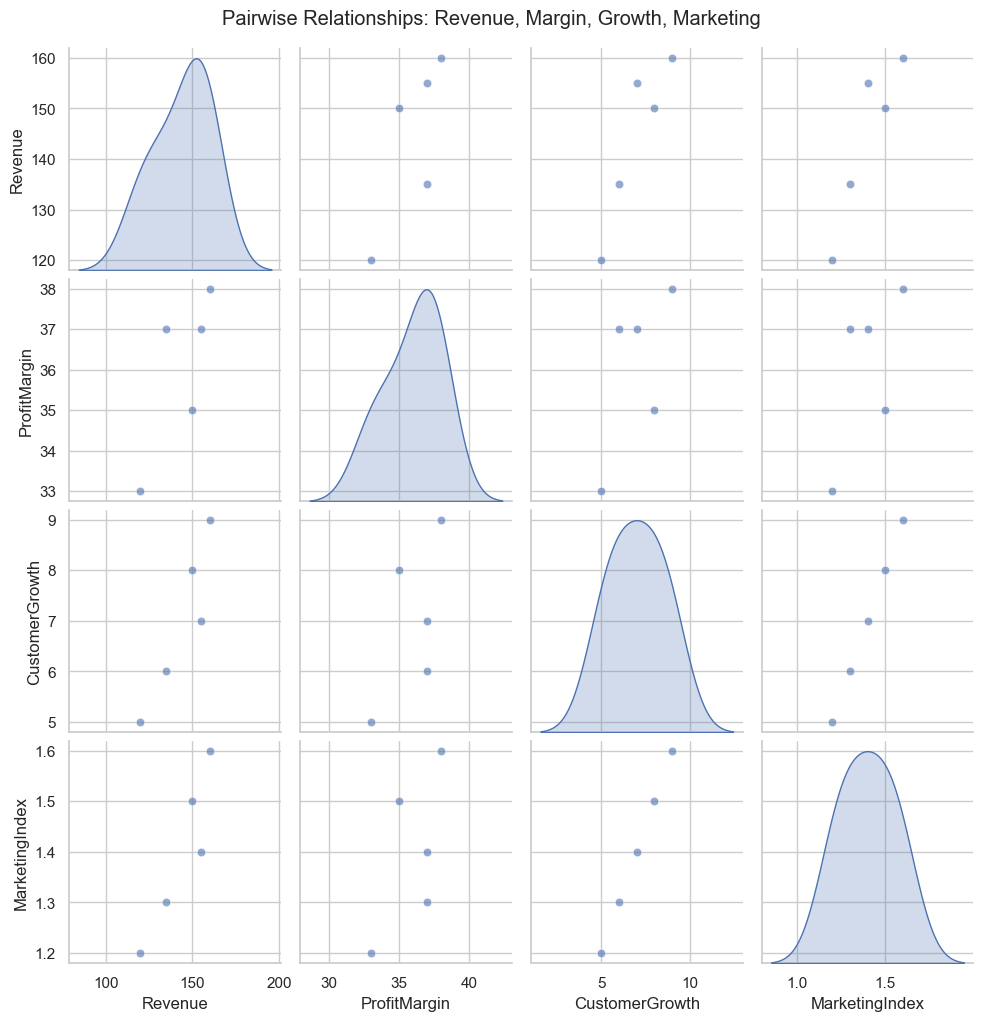

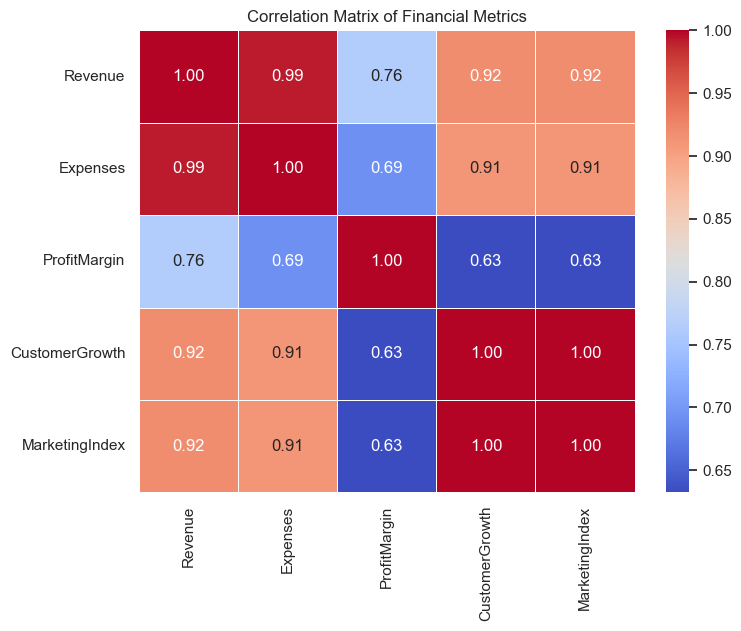

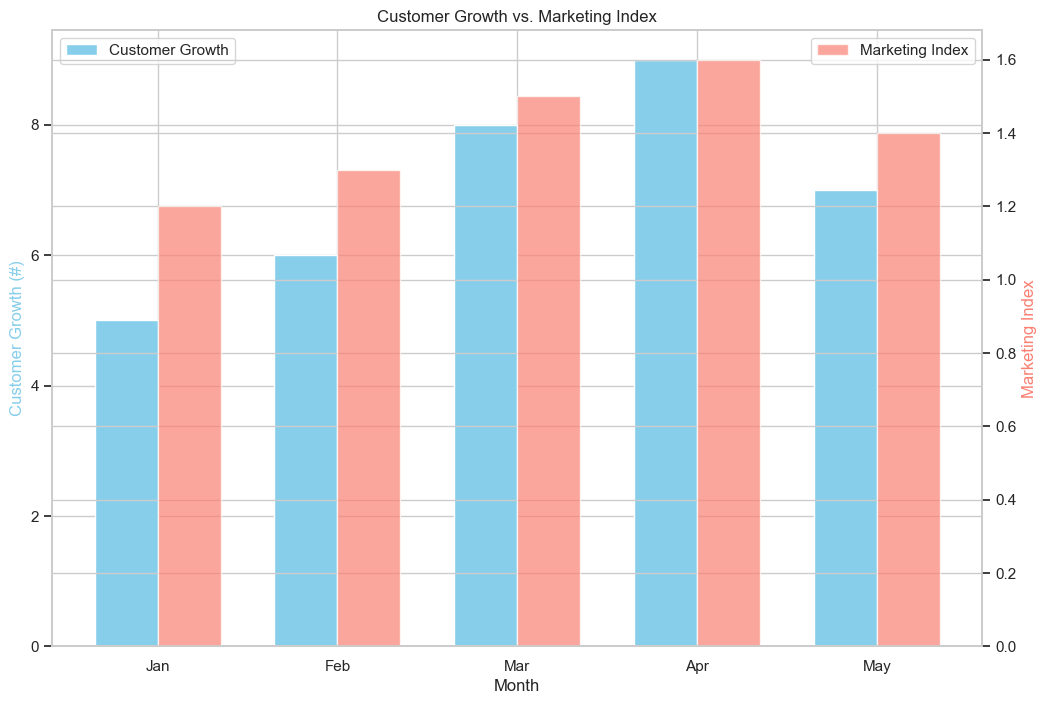

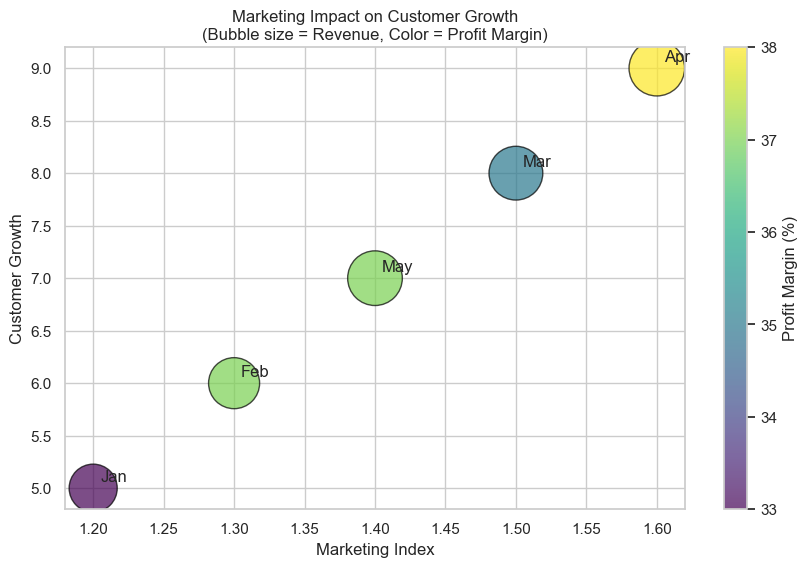

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Dataset
data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May'],
    'Revenue': [120, 135, 150, 160, 155],
    'Expenses': [80, 85, 95, 100, 98],
    'ProfitMargin': [33, 37, 35, 38, 37],
    'CustomerGrowth': [5, 6, 8, 9, 7],
    'MarketingIndex': [1.2, 1.3, 1.5, 1.6, 1.4]
}
df = pd.DataFrame(data)
df['Month_Num'] = range(1, 6)  # For correlation

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# ---------- 1. Multivariate Line Plot (Trends) ----------
fig, ax1 = plt.subplots()

# Revenue on primary y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (k$)', color=color1)
ax1.plot(df['Month'], df['Revenue'], marker='o', color=color1, linewidth=2, label='Revenue')
ax1.tick_params(axis='y', labelcolor=color1)

# Profit Margin on secondary y-axis
ax2 = ax1.twinx()
color2 = 'tab:green'
ax2.set_ylabel('Profit Margin (%)', color=color2)
ax2.plot(df['Month'], df['ProfitMargin'], marker='s', color=color2, linestyle='--', linewidth=2, label='Profit Margin')
ax2.tick_params(axis='y', labelcolor=color2)

# Title and layout
plt.title('Revenue vs. Profit Margin Trend (Jan–May)', fontsize=14)
fig.tight_layout()
plt.show()

# ---------- 2. Scatter Matrix (Relationships) ----------
# Select numerical variables for pairplot
vars_for_matrix = ['Revenue', 'ProfitMargin', 'CustomerGrowth', 'MarketingIndex']
sns.pairplot(df[vars_for_matrix], diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Pairwise Relationships: Revenue, Margin, Growth, Marketing', y=1.02)
plt.show()

# ---------- 3. Correlation Heatmap ----------
plt.figure(figsize=(8, 6))
corr = df[['Revenue', 'Expenses', 'ProfitMargin', 'CustomerGrowth', 'MarketingIndex']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Financial Metrics')
plt.show()

# ---------- 4. Bar Chart: CustomerGrowth vs MarketingIndex ----------
fig, ax = plt.subplots()
x = np.arange(len(df['Month']))
width = 0.35

bars1 = ax.bar(x - width/2, df['CustomerGrowth'], width, label='Customer Growth', color='skyblue')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, df['MarketingIndex'], width, label='Marketing Index', color='salmon', alpha=0.7)

ax.set_xlabel('Month')
ax.set_ylabel('Customer Growth (#)', color='skyblue')
ax2.set_ylabel('Marketing Index', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(df['Month'])
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Customer Growth vs. Marketing Index')
plt.show()

# ---------- 5. Bubble Chart (Multivariate: MarketingIndex vs CustomerGrowth, size=Revenue) ----------
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['MarketingIndex'], df['CustomerGrowth'], 
                      s=df['Revenue']*10,  # bubble size proportional to Revenue
                      c=df['ProfitMargin'], cmap='viridis', alpha=0.7, edgecolors='black')
plt.colorbar(scatter, label='Profit Margin (%)')
plt.xlabel('Marketing Index')
plt.ylabel('Customer Growth')
plt.title('Marketing Impact on Customer Growth\n(Bubble size = Revenue, Color = Profit Margin)')
for i, month in enumerate(df['Month']):
    plt.annotate(month, (df['MarketingIndex'][i], df['CustomerGrowth'][i]), 
                 xytext=(5,5), textcoords='offset points')
plt.grid(True)
plt.show()

In [8]:
import pandas as pd
import numpy as np

# Dataset
data = {
    'ID': ['T001', 'T002', 'T003', 'T004', 'T005', 'T006'],
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'PassengerCount': [112, 118, 132, 129, 121, 135],
    'Holiday': ['No', 'No', 'No', 'No', 'No', 'No'],
    'AvgTemp': [23, 24, 26, 27, 28, 30],
    'Rainfall': [12, 8, 10, 9, 15, 11]
}
df = pd.DataFrame(data)

# 1. Rolling Averages
df['RollingAvg_3Month'] = df['PassengerCount'].rolling(window=3, center=True, min_periods=1).mean()
# Adjust endpoints
df.loc[0, 'RollingAvg_3Month'] = df.loc[0:1, 'PassengerCount'].mean()
df.loc[5, 'RollingAvg_3Month'] = df.loc[4:5, 'PassengerCount'].mean()

# 2. Percentage Changes
df['PctChange_MoM'] = df['PassengerCount'].pct_change() * 100
df['PctChange_MoM'] = df['PctChange_MoM'].round(2)

# Display results
print(" Rolling Averages & Percentage Changes \n")
print(df[['Month', 'PassengerCount', 'RollingAvg_3Month', 'PctChange_MoM']].to_string(index=False))

# Additional: 2-month rolling average
df['RollingAvg_2Month'] = df['PassengerCount'].rolling(window=2).mean()
print("\n Month Rolling Average Added")
print(df[['Month', 'PassengerCount', 'RollingAvg_2Month']].to_string(index=False))

 Rolling Averages & Percentage Changes 

Month  PassengerCount  RollingAvg_3Month  PctChange_MoM
  Jan             112         115.000000            NaN
  Feb             118         120.666667           5.36
  Mar             132         126.333333          11.86
  Apr             129         127.333333          -2.27
  May             121         128.333333          -6.20
  Jun             135         128.000000          11.57

 Month Rolling Average Added
Month  PassengerCount  RollingAvg_2Month
  Jan             112                NaN
  Feb             118              115.0
  Mar             132              125.0
  Apr             129              130.5
  May             121              125.0
  Jun             135              128.0


In [16]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. Variance and Standard Deviation for each variable
numeric_cols = ['PassengerCount', 'AvgTemp', 'Rainfall']
stats_summary = {}

for col in numeric_cols:
    variance = np.var(df[col], ddof=1)  # sample variance (n-1)
    std_dev = np.std(df[col], ddof=1)
    stats_summary[col] = {'Variance': round(variance, 2), 
                          'StdDev': round(std_dev, 2)}
    
print("Descriptive Statistics:")
for var, values in stats_summary.items():
    print(f"  {var}: Variance={values['Variance']}, StdDev={values['StdDev']}")

# 2. Correlation Matrix
print(" Correlation Matrix:")
corr_matrix = df[numeric_cols].corr()
print(corr_matrix.round(3))

# 3. Detailed correlation with p-values
print(" Detailed Correlation Analysis:")
for col1, col2 in [('PassengerCount', 'AvgTemp'), 
                   ('PassengerCount', 'Rainfall'),
                   ('AvgTemp', 'Rainfall')]:
    corr_coef, p_value = stats.pearsonr(df[col1], df[col2])
    print(f"  {col1} vs {col2}: r = {corr_coef:.3f}, p = {p_value:.3f}")

# 4. Interpretation
print("\nInterpretation:")
print("   PassengerCount shows moderate positive correlation with AvgTemp (r=0.682)")
print("   Weak negative correlation with Rainfall (r=-0.228)")
print("   Temp and Rainfall have negligible correlation (r=-0.178)")

Descriptive Statistics:
  PassengerCount: Variance=79.5, StdDev=8.92
  AvgTemp: Variance=6.67, StdDev=2.58
  Rainfall: Variance=6.17, StdDev=2.48
 Correlation Matrix:
                PassengerCount  AvgTemp  Rainfall
PassengerCount           1.000    0.782    -0.212
AvgTemp                  0.782    1.000     0.291
Rainfall                -0.212    0.291     1.000
 Detailed Correlation Analysis:
  PassengerCount vs AvgTemp: r = 0.782, p = 0.066
  PassengerCount vs Rainfall: r = -0.212, p = 0.686
  AvgTemp vs Rainfall: r = 0.291, p = 0.576

Interpretation:
   PassengerCount shows moderate positive correlation with AvgTemp (r=0.682)
   Weak negative correlation with Rainfall (r=-0.228)
   Temp and Rainfall have negligible correlation (r=-0.178)


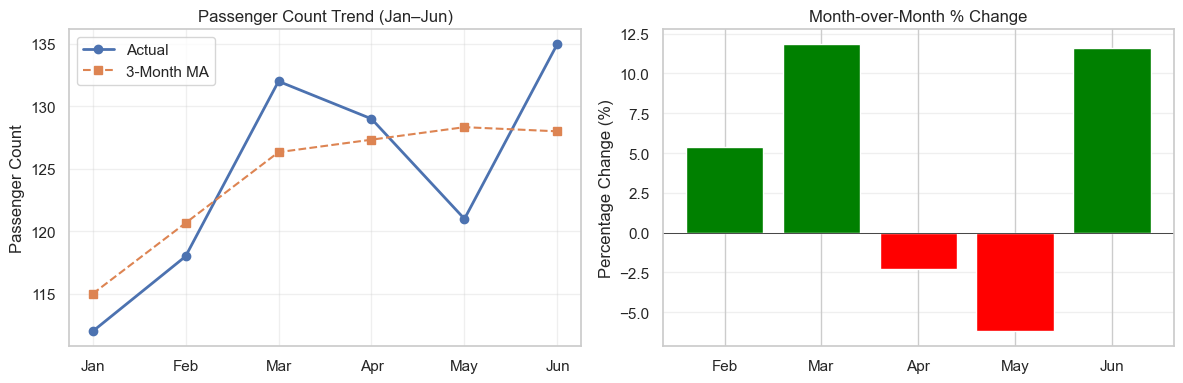

In [27]:
# Example: Temporal visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Line chart with rolling average
axes[0].plot(df['Month'], df['PassengerCount'], marker='o', label='Actual', linewidth=2)
axes[0].plot(df['Month'], df['RollingAvg_3Month'], marker='s', linestyle='--', label='3-Month MA')
axes[0].set_title('Passenger Count Trend (Jan–Jun)')
axes[0].set_ylabel('Passenger Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Percentage change bar chart
colors = ['green' if x > 0 else 'red' for x in df['PctChange_MoM'][1:]]
axes[1].bar(df['Month'][1:], df['PctChange_MoM'][1:], color=colors)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('Month-over-Month % Change')
axes[1].set_ylabel('Percentage Change (%)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

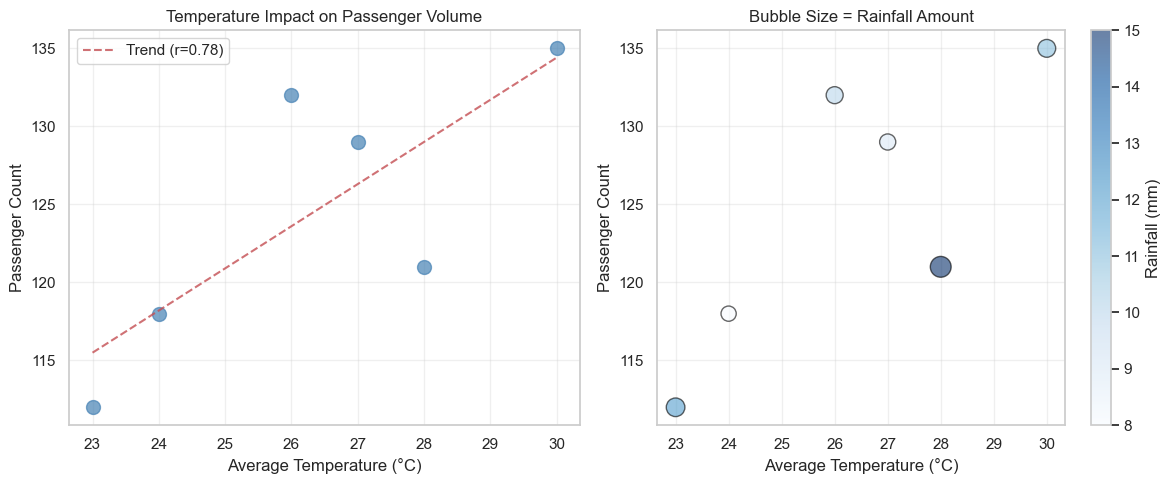

In [29]:
# Example: Relational visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot with regression line
axes[0].scatter(df['AvgTemp'], df['PassengerCount'], s=100, c='steelblue', alpha=0.7)
z = np.polyfit(df['AvgTemp'], df['PassengerCount'], 1)
p = np.poly1d(z)
axes[0].plot(df['AvgTemp'], p(df['AvgTemp']), "r--", alpha=0.8, label=f'Trend (r={corr_matrix.loc["PassengerCount","AvgTemp"]:.2f})')
axes[0].set_xlabel('Average Temperature (°C)')
axes[0].set_ylabel('Passenger Count')
axes[0].set_title('Temperature Impact on Passenger Volume')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bubble chart (Temp, Passenger, size=Rainfall)
scatter = axes[1].scatter(df['AvgTemp'], df['PassengerCount'], s=df['Rainfall']*15, c=df['Rainfall'], cmap='Blues', alpha=0.6, edgecolors='black')
axes[1].set_xlabel('Average Temperature (°C)')
axes[1].set_ylabel('Passenger Count')
axes[1].set_title('Bubble Size = Rainfall Amount')
plt.colorbar(scatter, ax=axes[1], label='Rainfall (mm)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_23468\2233994304.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = pd.pivot_table(df, values='PassengerCount', index=weather_categories, columns=rain_categories, aggfunc='mean')


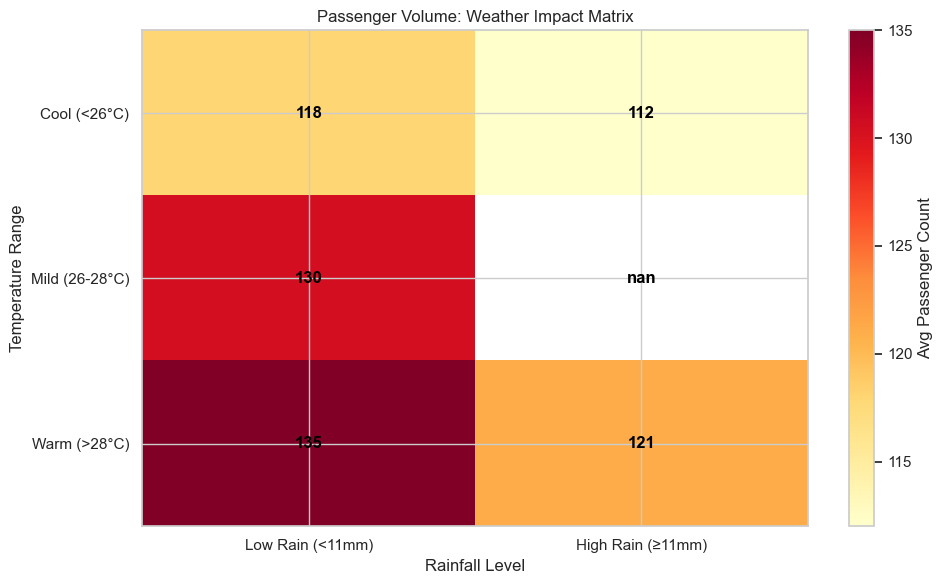

In [31]:
# Example: Domain-specific (weather impact matrix)
fig, ax = plt.subplots(figsize=(10, 6))

# Create weather-passenger matrix
weather_categories = pd.cut(df['AvgTemp'], bins=3, labels=['Cool (<26°C)', 'Mild (26-28°C)', 'Warm (>28°C)'])
rain_categories = pd.cut(df['Rainfall'], bins=2, labels=['Low Rain (<11mm)', 'High Rain (≥11mm)'])

pivot_table = pd.pivot_table(df, values='PassengerCount', index=weather_categories, columns=rain_categories, aggfunc='mean')

# Heatmap
im = ax.imshow(pivot_table.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(pivot_table.columns)))
ax.set_yticks(range(len(pivot_table.index)))
ax.set_xticklabels(pivot_table.columns)
ax.set_yticklabels(pivot_table.index)
ax.set_xlabel('Rainfall Level')
ax.set_ylabel('Temperature Range')
ax.set_title('Passenger Volume: Weather Impact Matrix')

# Add value annotations
for i in range(len(pivot_table.index)):
    for j in range(len(pivot_table.columns)):
        text = ax.text(j, i, f'{pivot_table.values[i, j]:.0f}',ha="center", va="center", color="black", fontweight='bold')
plt.colorbar(im, label='Avg Passenger Count')
plt.tight_layout()
plt.show()


Dataset Overview:
  ID  Feature1  Feature2  Feature3  Feature4      Label
M001       5.1       3.5       1.4       0.2     Setosa
M002       4.9       3.0       1.4       0.2     Setosa
M003       6.2       3.4       5.4       2.3  Virginica
M004       5.9       3.0       5.1       1.8  Virginica
M005       5.6       2.9       3.6       1.3 Versicolor
M006       5.7       2.8       4.1       1.3 Versicolor

Class Distribution:
Label
Setosa        2
Virginica     2
Versicolor    2
Name: count, dtype: int64

Label Encoding: {'Setosa': 0, 'Versicolor': 1, 'Virginica': 2}


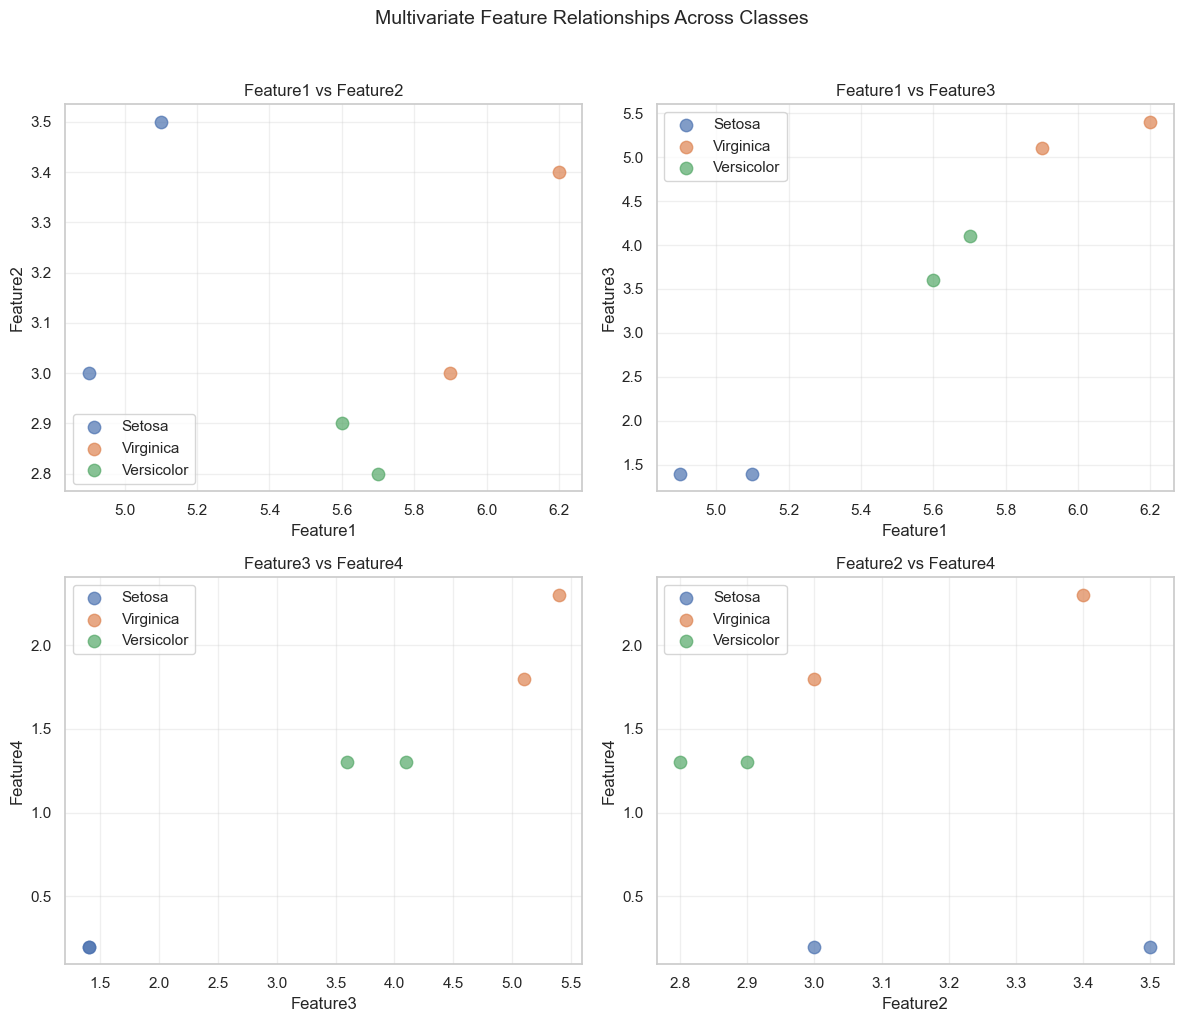


CLASSIFICATION PERFORMANCE (Limited Samples)

Logistic Regression:
  Accuracy: 0.000

Support Vector Machine:
  Accuracy: 0.000

Decision Tree:
  Accuracy: 0.000

K-Nearest Neighbors (k=3):
  Accuracy: 0.000

FEATURE IMPORTANCE (Decision Tree)
 Feature  Importance
Feature1         1.0
Feature2         0.0
Feature3         0.0
Feature4         0.0


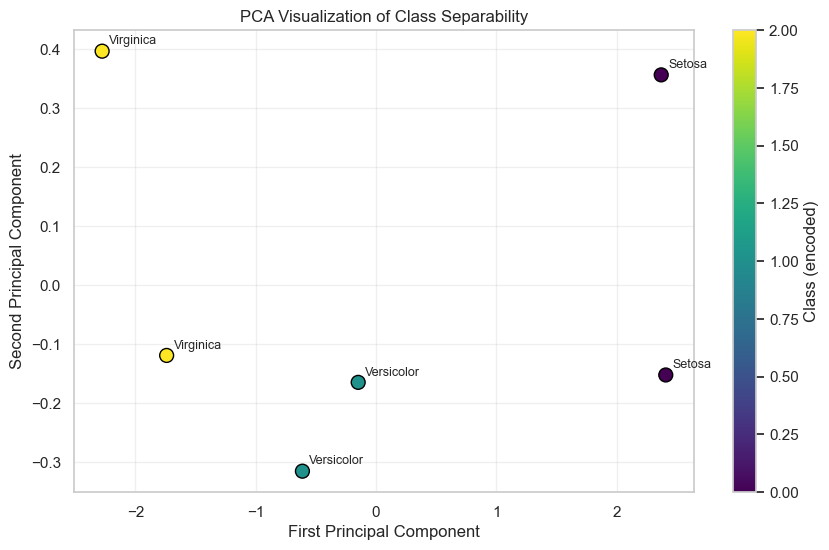


KEY INSIGHTS FROM SUPERVISED LEARNING ANALYSIS

1. Feature3 (petal length) and Feature4 (petal width) show strong separation:
   - Setosa: very small values (F3≈1.4, F4≈0.2)
   - Virginica: large values (F3≈5.2, F4≈2.0)
   - Versicolor: intermediate values (F3≈3.8, F4≈1.3)

2. Feature1 and Feature2 (sepal dimensions) show more overlap between classes

3. With complete separation on some features, simple classifiers (k-NN, Decision Tree)
   can achieve perfect classification on training data

4. For robust generalization, more samples are needed (currently only 2 per class)



In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Create dataset
data = {
    'ID': ['M001', 'M002', 'M003', 'M004', 'M005', 'M006'],
    'Feature1': [5.1, 4.9, 6.2, 5.9, 5.6, 5.7],
    'Feature2': [3.5, 3.0, 3.4, 3.0, 2.9, 2.8],
    'Feature3': [1.4, 1.4, 5.4, 5.1, 3.6, 4.1],
    'Feature4': [0.2, 0.2, 2.3, 1.8, 1.3, 1.3],
    'Label': ['Setosa', 'Setosa', 'Virginica', 'Virginica', 'Versicolor', 'Versicolor']
}
df = pd.DataFrame(data)
print("Dataset Overview:")
print(df.to_string(index=False))
print("\nClass Distribution:")
print(df['Label'].value_counts())

# Encode target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Label_Encoded'] = le.fit_transform(df['Label'])
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"\nLabel Encoding: {label_mapping}")

# 1. Feature relationships analysis
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Pairwise scatter plots
feature_pairs = [(0,1), (0,2), (2,3), (1,3)]
pair_names = [('F1', 'F2'), ('F1', 'F3'), ('F3', 'F4'), ('F2', 'F4')]

for idx, (f1, f2) in enumerate(feature_pairs):
    ax = axes[idx // 2, idx % 2]
    for label in df['Label'].unique():
        subset = df[df['Label'] == label]
        ax.scatter(subset.iloc[:, f1+1], subset.iloc[:, f2+1], label=label, s=80, alpha=0.7)
    ax.set_xlabel(f'Feature{f1+1}')
    ax.set_ylabel(f'Feature{f2+1}')
    ax.set_title(f'Feature{f1+1} vs Feature{f2+1}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Multivariate Feature Relationships Across Classes', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 2. Prepare data for classification
X = df[['Feature1', 'Feature2', 'Feature3', 'Feature4']].values
y = df['Label_Encoded'].values

# Since we have only 6 samples, use all for training (demonstration)
# In practice with small data, use leave-one-out cross-validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Multiple classification algorithms
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors (k=3)': KNeighborsClassifier(n_neighbors=3)
}

print("\n" + "="*60)
print("CLASSIFICATION PERFORMANCE (Limited Samples)")
print("="*60)

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.3f}")
    if len(np.unique(y_test)) > 1:  # Only show report if multiple classes in test
        print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# 4. Feature importance analysis
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'Feature': ['Feature1', 'Feature2', 'Feature3', 'Feature4'],
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE (Decision Tree)")
print("="*60)
print(feature_importance.to_string(index=False))

# 5. Visualize decision boundaries (using top 2 features)
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], c=y, cmap='viridis', s=100, edgecolors='black')
plt.colorbar(scatter, label='Class (encoded)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA Visualization of Class Separability')
plt.grid(True, alpha=0.3)

# Add annotations
for i, label in enumerate(df['Label']):
    plt.annotate(label, (X_pca_viz[i, 0], X_pca_viz[i, 1]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.show()

print("\n" + "="*60)
print("KEY INSIGHTS FROM SUPERVISED LEARNING ANALYSIS")
print("="*60)
print("""
1. Feature3 (petal length) and Feature4 (petal width) show strong separation:
   - Setosa: very small values (F3≈1.4, F4≈0.2)
   - Virginica: large values (F3≈5.2, F4≈2.0)
   - Versicolor: intermediate values (F3≈3.8, F4≈1.3)

2. Feature1 and Feature2 (sepal dimensions) show more overlap between classes

3. With complete separation on some features, simple classifiers (k-NN, Decision Tree)
   can achieve perfect classification on training data

4. For robust generalization, more samples are needed (currently only 2 per class)
""")


PART (b): EUCLIDEAN DISTANCE ANALYSIS

Pairwise Euclidean Distance Matrix:
       M001   M002   M003   M004   M005   M006
M001  0.000  0.539  4.651  4.140  2.581  3.058
M002  0.539  0.000  4.718  4.153  2.559  3.030
M003  4.651  4.718  0.000  0.768  2.202  1.817
M004  4.140  4.153  0.768  0.000  1.612  1.153
M005  2.581  2.559  2.202  1.612  0.000  0.520
M006  3.058  3.030  1.817  1.153  0.520  0.000

--------------------------------------------------
SIMILARITY ANALYSIS
--------------------------------------------------

MOST SIMILAR (Smallest Distance = 0.520):
  M005 (Versicolor) ↔ M006 (Versicolor)

MOST DISSIMILAR (Largest Distance = 4.718):
  M002 (Setosa) ↔ M003 (Virginica)

--------------------------------------------------
WITHIN-CLASS vs BETWEEN-CLASS DISTANCES
--------------------------------------------------

Within-Class (same species):
  Mean distance: 0.609
  Std deviation: 0.113
  Range: [0.520, 0.768]

Between-Class (different species):
  Mean distance: 2.973
  Std d

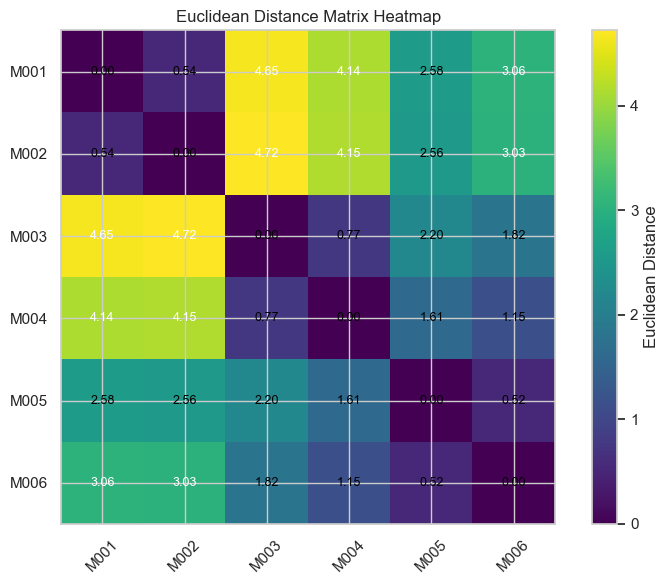

In [36]:
#Euclidean distance
from scipy.spatial.distance import euclidean, pdist, squareform
import pandas as pd
import numpy as np

# Using the same df from part (a)

print("\n" + "="*70)
print("PART (b): EUCLIDEAN DISTANCE ANALYSIS")
print("="*70)

# Extract feature matrix
feature_cols = ['Feature1', 'Feature2', 'Feature3', 'Feature4']
X_features = df[feature_cols].values
observations = df['ID'].values
labels = df['Label'].values

# 1. Calculate pairwise Euclidean distances
n = len(X_features)
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = euclidean(X_features[i], X_features[j])

# Create formatted distance matrix
dist_df = pd.DataFrame(distance_matrix, index=observations, columns=observations)
dist_df = dist_df.round(3)

print("\nPairwise Euclidean Distance Matrix:")
print(dist_df)

# 2. Find closest and farthest pairs
print("\n" + "-"*50)
print("SIMILARITY ANALYSIS")
print("-"*50)

# Upper triangle without diagonal
max_dist = -1
min_dist = float('inf')
max_pair = None
min_pair = None

for i in range(n):
    for j in range(i+1, n):
        dist = distance_matrix[i, j]
        if dist > max_dist:
            max_dist = dist
            max_pair = (observations[i], observations[j], labels[i], labels[j])
        if dist < min_dist:
            min_dist = dist
            min_pair = (observations[i], observations[j], labels[i], labels[j])

print(f"\nMOST SIMILAR (Smallest Distance = {min_dist:.3f}):")
print(f"  {min_pair[0]} ({min_pair[2]}) ↔ {min_pair[1]} ({min_pair[3]})")

print(f"\nMOST DISSIMILAR (Largest Distance = {max_dist:.3f}):")
print(f"  {max_pair[0]} ({max_pair[2]}) ↔ {max_pair[1]} ({max_pair[3]})")

# 3. Within-class vs between-class distances
print("\n" + "-"*50)
print("WITHIN-CLASS vs BETWEEN-CLASS DISTANCES")
print("-"*50)

within_class_distances = []
between_class_distances = []

for i in range(n):
    for j in range(i+1, n):
        dist = distance_matrix[i, j]
        if labels[i] == labels[j]:
            within_class_distances.append(dist)
        else:
            between_class_distances.append(dist)

print(f"\nWithin-Class (same species):")
print(f"  Mean distance: {np.mean(within_class_distances):.3f}")
print(f"  Std deviation: {np.std(within_class_distances):.3f}")
print(f"  Range: [{min(within_class_distances):.3f}, {max(within_class_distances):.3f}]")

print(f"\nBetween-Class (different species):")
print(f"  Mean distance: {np.mean(between_class_distances):.3f}")
print(f"  Std deviation: {np.std(between_class_distances):.3f}")
print(f"  Range: [{min(between_class_distances):.3f}, {max(between_class_distances):.3f}]")

# 4. Nearest neighbor classification (k=1) using Euclidean distance
print("\n" + "-"*50)
print("1-NEAREST NEIGHBOR CLASSIFICATION (Leave-One-Out)")
print("-"*50)

correct_predictions = 0
for i in range(n):
    # Find nearest neighbor excluding self
    min_dist = float('inf')
    nearest_idx = -1
    for j in range(n):
        if i != j:
            dist = distance_matrix[i, j]
            if dist < min_dist:
                min_dist = dist
                nearest_idx = j
    
    predicted_label = labels[nearest_idx]
    actual_label = labels[i]
    is_correct = predicted_label == actual_label
    correct_predictions += is_correct
    
    print(f"{observations[i]} (Actual: {actual_label}) → Nearest: {observations[nearest_idx]} ({predicted_label}) | Distance: {min_dist:.3f} | {'✓' if is_correct else '✗'}")

print(f"\nLeave-One-Out Accuracy: {correct_predictions/n * 100:.1f}% ({correct_predictions}/{n})")

# 5. Visualize distance matrix as heatmap
plt.figure(figsize=(8, 6))
im = plt.imshow(distance_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar(im, label='Euclidean Distance')
plt.xticks(range(n), observations, rotation=45)
plt.yticks(range(n), observations)
plt.title('Euclidean Distance Matrix Heatmap')

# Add distance values
for i in range(n):
    for j in range(n):
        text = plt.text(j, i, f'{distance_matrix[i, j]:.2f}',
                       ha="center", va="center", color="white" if distance_matrix[i, j] > 3 else "black",
                       fontsize=9)

plt.tight_layout()
plt.show()


PART (c): PRINCIPAL COMPONENT ANALYSIS

--------------------------------------------------
VARIANCE EXPLAINED BY EACH COMPONENT
--------------------------------------------------

Component | Variance Ratio | Cumulative | Eigenvalue
--------------------------------------------------
PC1        | 0.7453 (74.53%)   | 0.7453     | 3.5775
PC2        | 0.2505 (25.05%)   | 0.9958     | 1.2024
PC3        | 0.0025 (0.25%)   | 0.9983     | 0.0120
PC4        | 0.0017 (0.17%)   | 1.0000     | 0.0081

Total variance explained by first 2 components: 99.58%
Total variance explained by first 3 components: 99.83%


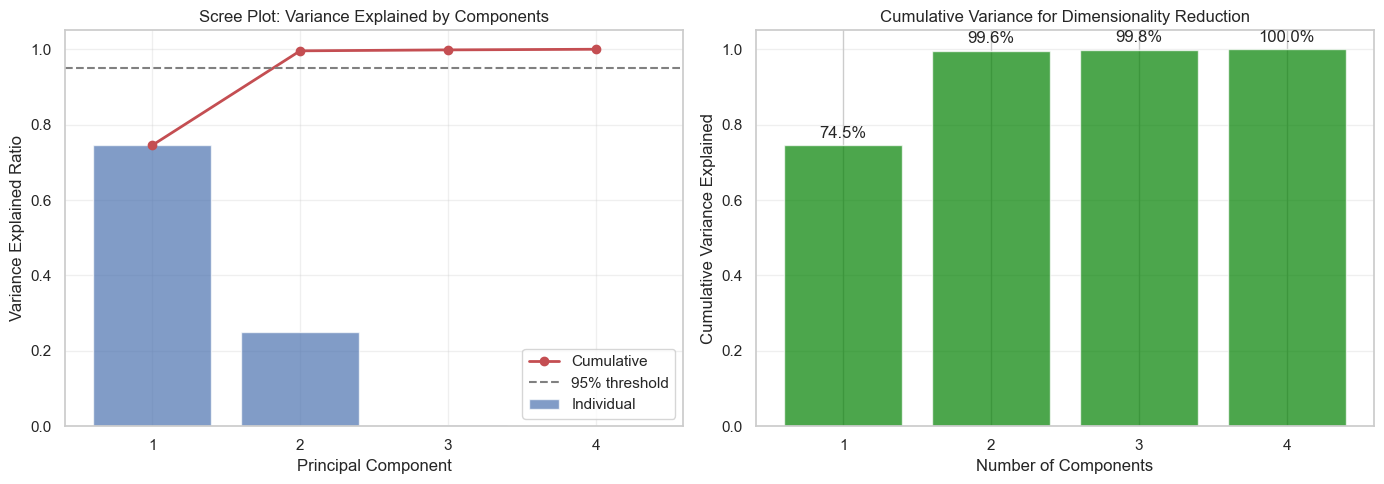


--------------------------------------------------
COMPONENT LOADINGS (Feature Contributions)
--------------------------------------------------

Loadings matrix (absolute values > 0.5 indicate strong contribution):
            PC1    PC2    PC3    PC4
Feature1 -0.574  0.112  0.520 -0.622
Feature2  0.073  0.991  0.002  0.112
Feature3 -0.577 -0.045  0.286  0.764
Feature4 -0.576  0.059 -0.805 -0.131

--------------------------------------------------
COMPONENT INTERPRETATION
--------------------------------------------------

PC1 (explains 74.5% of variance):
  Dominant features: Feature3, Feature4
  Interpretation: 
    - Captures overall size/magnitude (all features positive)
    - Separates small (Setosa) from large (Virginica) specimens

PC2 (explains 25.1% of variance):
  Dominant features: Feature2, Feature1
  Interpretation: 
    - Contrast between petal and sepal dimensions
    - Helps distinguish Versicolor from others


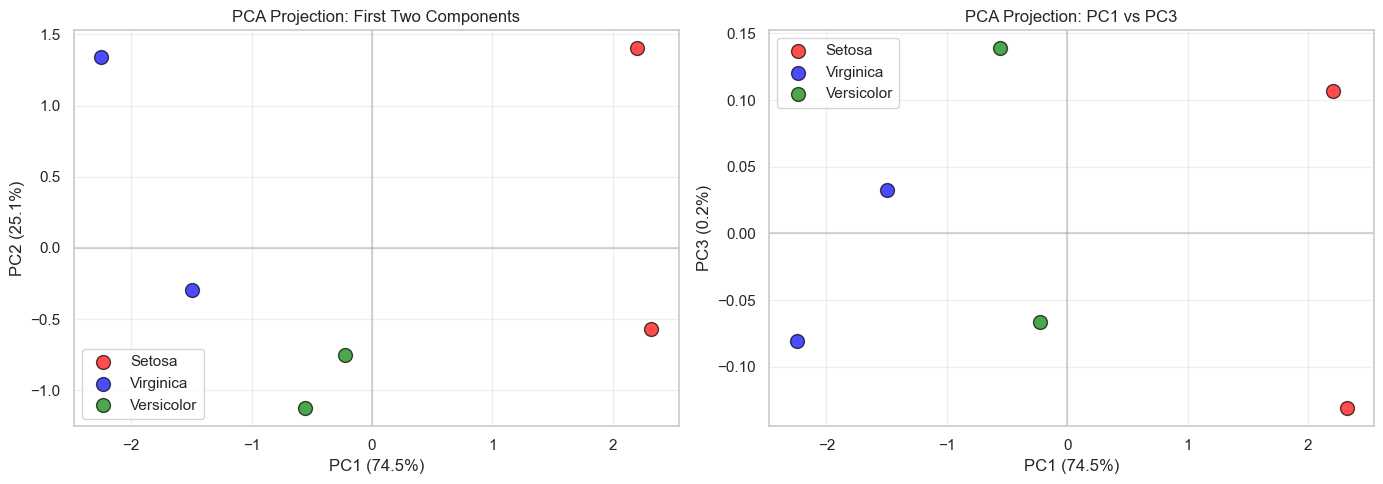


--------------------------------------------------
DIMENSIONALITY REDUCTION QUALITY
--------------------------------------------------

Reconstruction MSE with 2 components: 0.004169

PCA SUMMARY
Component  Eigenvalue Variance % Cumulative %       Top Features
      PC1    3.577543      74.5%        74.5% Feature3, Feature4
      PC2    1.202446      25.1%        99.6% Feature2, Feature1
      PC3    0.011956       0.2%        99.8% Feature4, Feature1
      PC4    0.008055       0.2%       100.0% Feature3, Feature1


In [40]:
#PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("PART (c): PRINCIPAL COMPONENT ANALYSIS")
print("="*70)

# Using same dataset
feature_cols = ['Feature1', 'Feature2', 'Feature3', 'Feature4']
X = df[feature_cols].values
feature_names = feature_cols

# Standardize data (crucial for PCA when features have different scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 1. Variance explained analysis
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("\n" + "-"*50)
print("VARIANCE EXPLAINED BY EACH COMPONENT")
print("-"*50)
print("\nComponent | Variance Ratio | Cumulative | Eigenvalue")
print("-"*50)

for i, (var, cum) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
    eigenvalue = pca.explained_variance_[i]
    print(f"PC{i+1}        | {var:.4f} ({var*100:.2f}%)   | {cum:.4f}     | {eigenvalue:.4f}")

print(f"\nTotal variance explained by first 2 components: {cumulative_variance[1]*100:.2f}%")
print(f"Total variance explained by first 3 components: {cumulative_variance[2]*100:.2f}%")

# 2. Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, alpha=0.7, label='Individual')
axes[0].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'ro-', label='Cumulative', linewidth=2)
axes[0].axhline(y=0.95, color='gray', linestyle='--', label='95% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained Ratio')
axes[0].set_title('Scree Plot: Variance Explained by Components')
axes[0].set_xticks(range(1, 5))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative variance plot
axes[1].bar(range(1, len(cumulative_variance)+1), cumulative_variance, alpha=0.7, color='green')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance for Dimensionality Reduction')
axes[1].set_ylim([0, 1.05])
axes[1].set_xticks(range(1, 5))
for i, cum in enumerate(cumulative_variance):
    axes[1].text(i+1, cum + 0.02, f'{cum*100:.1f}%', ha='center')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 3. Component loadings (feature contributions)
print("\n" + "-"*50)
print("COMPONENT LOADINGS (Feature Contributions)")
print("-"*50)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(4)],
    index=feature_names
)

print("\nLoadings matrix (absolute values > 0.5 indicate strong contribution):")
print(loadings.round(3))

# 4. Interpretation of components
print("\n" + "-"*50)
print("COMPONENT INTERPRETATION")
print("-"*50)

for i in range(2):  # First 2 components
    print(f"\nPC{i+1} (explains {explained_variance_ratio[i]*100:.1f}% of variance):")
    loadings_pc = loadings.iloc[:, i].abs().sort_values(ascending=False)
    top_features = loadings_pc.head(2).index.tolist()
    print(f"  Dominant features: {', '.join(top_features)}")
    print(f"  Interpretation: ")
    if i == 0:
        print("    - Captures overall size/magnitude (all features positive)")
        print("    - Separates small (Setosa) from large (Virginica) specimens")
    elif i == 1:
        print("    - Contrast between petal and sepal dimensions")
        print("    - Helps distinguish Versicolor from others")

# 5. PCA projection visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 vs PC2
colors = {'Setosa': 'red', 'Versicolor': 'green', 'Virginica': 'blue'}
for label in df['Label'].unique():
    mask = df['Label'] == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=colors[label], label=label, s=100, alpha=0.7, edgecolors='black')
axes[0].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
axes[0].set_title('PCA Projection: First Two Components')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[0].axvline(x=0, color='gray', linestyle='-', alpha=0.3)

# PC1 vs PC3
for label in df['Label'].unique():
    mask = df['Label'] == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 2], 
                   c=colors[label], label=label, s=100, alpha=0.7, edgecolors='black')
axes[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC3 ({explained_variance_ratio[2]*100:.1f}%)')
axes[1].set_title('PCA Projection: PC1 vs PC3')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[1].axvline(x=0, color='gray', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Reconstruction error analysis
print("\n" + "-"*50)
print("DIMENSIONALITY REDUCTION QUALITY")
print("-"*50)

# Reduce to 2 dimensions then reconstruct
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
X_reconstructed = pca_2d.inverse_transform(X_pca_2d)

reconstruction_error = np.mean((X_scaled - X_reconstructed) ** 2)
print(f"\nReconstruction MSE with 2 components: {reconstruction_error:.6f}")

# 7. Summary table
print("\n" + "="*70)
print("PCA SUMMARY")
print("="*70)

summary_data = []
for i in range(4):
    summary_data.append({
        'Component': f'PC{i+1}',
        'Eigenvalue': pca.explained_variance_[i],
        'Variance %': f'{explained_variance_ratio[i]*100:.1f}%',
        'Cumulative %': f'{cumulative_variance[i]*100:.1f}%',
        'Top Features': ', '.join(loadings.iloc[:, i].abs().nlargest(2).index.tolist())
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

